In [22]:
from pathlib import Path
import zarr

base_path = Path('/Users/clairenastaskin/data/2025-04-02/sub-Forest001_ses-20250402_task-movements_run-01')  
zarr_path = base_path / 'sub-Forest001_ses-20250402_task-movements_run-01_iq.zarr'
zarr_path
data_zarr = zarr.open(zarr_path, mode="r", path="data")

In [23]:
print(data_zarr.shape)
# data_dimensions_unfolder = data_zarr[:,:,:,:,:].reshape(data_zarr.shape[0], data_zarr.shape[1], data_zarr.shape[2], data_zarr.shape[3]*data_zarr.shape[4], data_zarr.shape[5])


(187, 200, 1, 64, 138, 100)


dynamic range:  9.030900001525879


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_1962/3482429556.py:6: RuntimeWarning: divide by zero encountered in log10
  iq_image_dB = 20*np.log10(iq_image)


Text(0.5, 1.0, 'IQ data dB: middle azimuth slice')

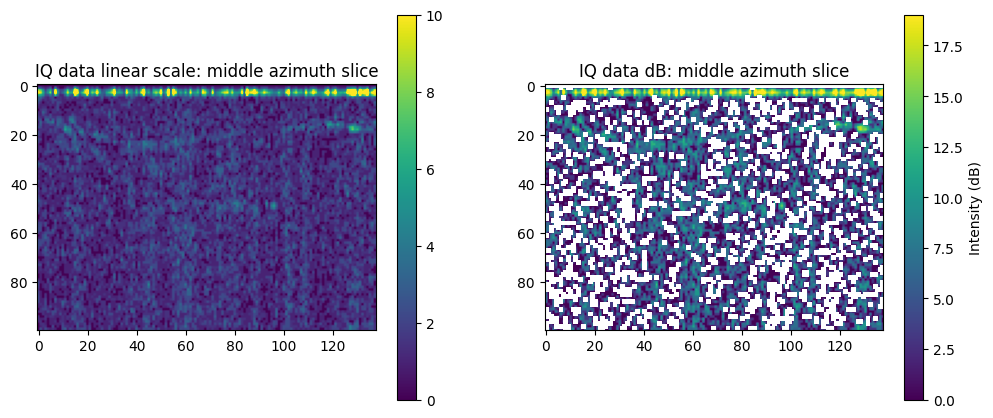

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

slice_to_plot = 32
iq_image = abs(data_zarr[0,0,0,slice_to_plot,:,:].T)
iq_image_dB = 20*np.log10(iq_image)

# Create a boolean mask identifying non-zero values in iq_image
# np.finfo().eps gives the smallest representable positive number for the data type
# Values below this threshold are considered effectively zero
# This mask will be used to calculate percentiles only on non-zero values
nnz_idx = iq_image > np.finfo(iq_image.dtype).eps
vmax = np.percentile(iq_image_dB[nnz_idx], 90)
vmin = np.percentile(iq_image_dB[nnz_idx], 10)
print('dynamic range: ', vmax-vmin)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax1.imshow(iq_image, vmax=10, vmin=0)
plt.colorbar(im1, ax=ax1)
ax1.set_title("IQ data linear scale: middle azimuth slice")

im2 = ax2.imshow(iq_image_dB, vmax=vmax+10, vmin=vmin)
plt.colorbar(im2, ax=ax2, label='Intensity (dB)')
ax2.set_title("IQ data dB: middle azimuth slice")

In [3]:
#############################################################
# Make a movie out the raw data along the azimuth dimension #
#############################################################
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
cax = ax.imshow(abs(data_zarr[0,0,0,:,0,:].T), cmap='jet')
plt.colorbar(cax, ax=ax, label='Intensity')
ax.set_title("Raw data: azimuth element 0")

def update(element):
    cax.set_data(abs(data_zarr[0,0,0,:,element,:].T))
    ax.set_title(f"Raw data: azimuth element {element}")

# Create animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

element_to_plot = range(0, data_zarr.shape[4])
ani = FuncAnimation(fig, update, frames=element_to_plot, interval=100)

# Display animation in notebook
display(HTML(ani.to_jshtml()))

# Close figure to prevent static display
plt.close(fig)

# Save animation
ani.save(base_path / "zarr_movie.mp4", writer="ffmpeg")